# Netlist & Schematic I/O

This page dives into the **Netlist data model** — the representation that kfactory uses
for connectivity — and shows how to:

- Inspect the `Netlist` object (instances, nets, ports)
- Serialize a schematic to JSON/YAML and reload it with `kf.read_schematic`
- Compare netlists and sort them for stable equality checks
- Handle electrically-equivalent ports (pads, bumps) with `lvs_equivalent`

For the schematic-first design workflow itself (placement, `connect`, LVS basics) see
the [Schematic-Driven Design](overview.py) page.

In [1]:
import json
import tempfile
from pathlib import Path

import kfactory as kf
from kfactory.netlist import NetlistPort, PortRef

## PDK setup

We reuse the same minimal PDK from the overview page — a straight waveguide and a 90 °
euler bend, both registered on a dedicated `KCLayout`.

In [2]:
class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


L = LAYER()
pdk = kf.KCLayout("SCHEM_NETLIST", infos=LAYER)


@pdk.cell
def straight(width: int, length: int) -> kf.KCell:
    """Straight waveguide segment.

    Args:
        width: Width in dbu.
        length: Length in dbu.
    """
    c = pdk.kcell()
    c.shapes(L.WG).insert(kf.kdb.Box(0, -width // 2, length, width // 2))
    c.create_port(
        name="o1",
        width=width,
        trans=kf.kdb.Trans(rot=2, mirrx=False, x=0, y=0),
        layer_info=L.WG,
    )
    c.create_port(
        name="o2",
        width=width,
        trans=kf.kdb.Trans(x=length, y=0),
        layer_info=L.WG,
    )
    return c


@pdk.cell
def bend90(width: int, radius: int) -> kf.KCell:
    """90° Euler bend.

    Args:
        width: Width in dbu.
        radius: Nominal bend radius in dbu.
    """
    return kf.factories.euler.bend_euler_factory(kcl=pdk)(
        width=pdk.to_um(width),
        radius=pdk.to_um(radius),
        layer=L.WG,
    )

## Building a schematic for inspection

A simple L-shaped path: `s1 → b1 → s2`.

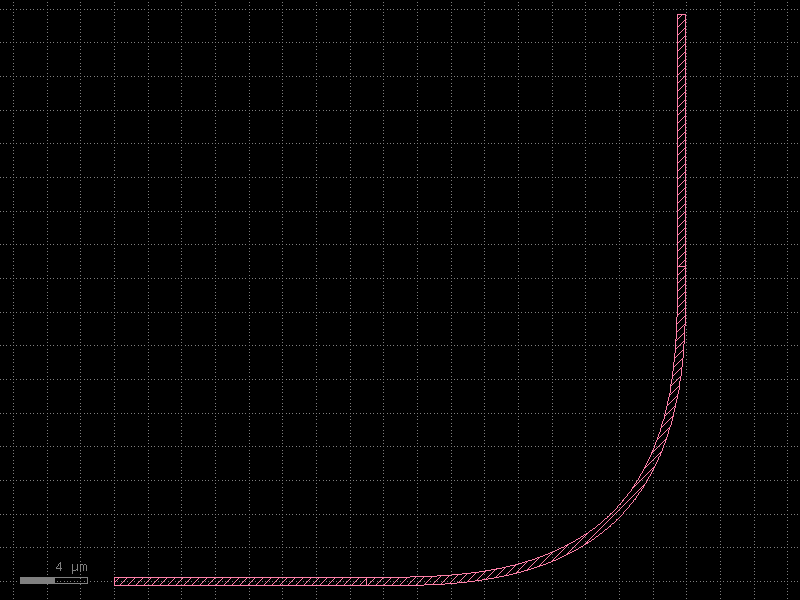

In [3]:
@pdk.schematic_cell
def l_path() -> kf.Schematic:
    schematic = kf.Schematic(kcl=pdk)

    s1 = schematic.create_inst("s1", "straight", {"width": 500, "length": 15_000})
    b1 = schematic.create_inst("b1", "bend90",   {"width": 500, "radius": 10_000})
    s2 = schematic.create_inst("s2", "straight", {"width": 500, "length": 15_000})

    s1.place(x=0, y=0)
    b1.connect("o1", s1.ports["o2"])
    s2.connect("o1", b1.ports["o2"])

    return schematic


cell = l_path()
cell

## The Netlist data model

`KCell.netlist()` returns a `dict[str, Netlist]` keyed by cell name.  Each `Netlist`
has three attributes:

| Attribute | Type | Meaning |
|-----------|------|---------|
| `instances` | `dict[str, NetlistInstance]` | Every sub-cell placed in this cell |
| `nets` | `list[Net]` | Each net is a list of `PortRef` / `NetlistPort` entries that are connected |
| `ports` | `list[NetlistPort]` | Top-level ports exposed by this cell |

A `PortRef` identifies a port by instance name and port name: `PortRef(instance="s1", port="o2")`.
A `NetlistPort` identifies a cell-level port by name.

In [4]:
netlists = cell.netlist()
nl = netlists[cell.name]

print(f"Instances ({len(nl.instances)}):")
for name, inst in nl.instances.items():
    print(f"  {name}: component={inst.component!r}  settings={inst.settings}")

print(f"\nNets ({len(nl.nets)}):")
for i, net in enumerate(nl.nets):
    parts = []
    for p in net.root:
        if isinstance(p, PortRef):
            parts.append(f"{p.instance}.{p.port}")
        else:
            parts.append(f"<cell-port:{p.name}>")
    print(f"  net[{i}]: {' — '.join(parts)}")

print(f"\nTop-level ports ({len(nl.ports)}): {[p.name for p in nl.ports]}")

Instances (3):
  b1: component='bend90'  settings={'width': 500, 'radius': 10000}
  s1: component='straight'  settings={'width': 500, 'length': 15000}
  s2: component='straight'  settings={'width': 500, 'length': 15000}

Nets (2):
  net[0]: b1.o1 — s1.o2
  net[1]: b1.o2 — s2.o1

Top-level ports (0): []


### Sorting nets for stable comparison

Port ordering within a net and the order of nets across the netlist can vary between
runs.  `Netlist.sort()` normalises both, making equality checks reproducible.

In [5]:
nl_a = cell.netlist()[cell.name]
nl_b = cell.netlist()[cell.name]

# sort() modifies in-place and returns self
nl_a.sort()
nl_b.sort()

assert nl_a == nl_b
print("Sorted netlists are equal ✓")

Sorted netlists are equal ✓


## Schematic serialization

A `Schematic` is a Pydantic model, so standard Pydantic serialization methods work
directly.

### JSON export

In [6]:
model = cell.schematic
raw_json = model.model_dump_json(indent=2)
data = json.loads(raw_json)

# Show the top-level keys present in the serialized schematic
print("Top-level keys:", list(data.keys()))

# Show the placements section
print("\nPlacements:")
for name, placement in data.get("placements", {}).items():
    print(f"  {name}: {placement}")

Top-level keys: ['name', 'instances', 'placements', 'nets', 'routes', 'ports', 'pins', 'constraints', 'unit', 'info']

Placements:
  s1: {'mirror': False, 'x': 0, 'dx': 0, 'y': 0, 'dy': 0, 'orientation': 0.0, 'anchor': None}


/home/runner/work/_temp/setup-uv-cache/archive-v0/DIuwhyOhYOSSx0D_/lib/python3.14/site-packages/pydantic/main.py:528: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `RouteNet[Annotated[int, str]]` - serialized value may not be as expected [field_name='nets', input_value=Connection[TypeVar](net=(...tance='s1', port='o2'))), input_type=Connection[TypeVar]])
  PydanticSerializationUnexpectedValue(Expected `Connection[Annotated[int, str]]` - serialized value may not be as expected [field_name='nets', input_value=Connection[TypeVar](net=(...tance='s1', port='o2'))), input_type=Connection[TypeVar]])
  PydanticSerializationUnexpectedValue(Expected `VirtualConnection[Annotated[int, str]]` - serialized value may not be as expected [field_name='nets', input_value=Connection[TypeVar](net=(...tance='s1', port='o2'))), input_type=Connection[TypeVar]])
  PydanticSerializationUnexpectedValue(Expected `RouteNet[Annotated[int, str]]` - serialized value may no

### YAML round-trip with `read_schematic`

Schematics are typically stored as YAML files for version control.  `kf.read_schematic`
loads them back into a `Schematic` (or `DSchematic` when `unit="um"`).

`Schematic` is also a Pydantic model, so `model_validate` works directly with a
dictionary from `yaml.safe_load` — or you can use the convenience `read_schematic` helper.

In [7]:
with tempfile.TemporaryDirectory() as tmpdir:
    yaml_path = Path(tmpdir) / "l_path.yaml"

    # Exclude the 'unit' field — it is fixed by the Schematic subclass and must not
    # be present in the serialized payload for read_schematic to accept it.
    yaml_path.write_text(model.model_dump_json(indent=2, exclude={"unit"}))

    # Read back. NOTE: a known upstream bug currently prevents the JSON
    # produced by `model_dump_json` from round-tripping through
    # `read_schematic` when nets are present (see kfactory issue tracker —
    # the `nets` validator expects `{"p1": ..., "p2": ...}` keys but
    # `model_dump_json` serialises them as nested arrays). The pattern is
    # shown for documentation; uncomment to test once the upstream fix lands.
    try:
        reloaded = kf.read_schematic(yaml_path, unit="dbu")
        print("Reloaded schematic instances:", list(reloaded.instances.keys()))
        print("Reloaded schematic placements:", list(reloaded.placements.keys()))
    except KeyError as exc:
        print(f"(known upstream round-trip bug — KeyError: {exc})")

(known upstream round-trip bug — KeyError: 'p1')


The reloaded schematic carries the same instance definitions and placements.
Calling `reloaded.create_cell(output_type=kf.KCell, factories={"straight": straight, "bend90": bend90})`
would materialise an identical physical cell.

## LVS with electrically-equivalent ports

Some components — pads, bumps, redistribution-layer vias — have multiple ports that
are **electrically equivalent**: they all connect to the same metal plane.  A naive LVS
comparison would fail because the extracted netlist tracks every individual port, while
the schematic may only declare one logical connection.

`Netlist.lvs_equivalent` folds equivalent ports into a single canonical name so that
the two netlists can be compared meaningfully.

### Defining a pad component with two equivalent ports

In [8]:
@pdk.cell
def pad(port_width: int, size: int) -> kf.KCell:
    """Square metal pad with two optical connections for demo purposes.

    In a real PDK this might be a bump or redistribution via where
    port 'p1' and 'p2' land on the same metal island.

    Args:
        port_width: Width of each connecting port in dbu (must match the waveguide).
        size: Side length of the square pad body in dbu.
    """
    c = pdk.kcell()
    c.shapes(L.WG).insert(kf.kdb.Box(0, 0, size, size))
    # Two ports on opposite edges — electrically the same metal
    c.create_port(
        name="p1",
        width=port_width,
        trans=kf.kdb.Trans(rot=2, mirrx=False, x=0, y=size // 2),
        layer_info=L.WG,
    )
    c.create_port(
        name="p2",
        width=port_width,
        trans=kf.kdb.Trans(x=size, y=size // 2),
        layer_info=L.WG,
    )
    return c

### Building and extracting a netlist that contains the pad

In [9]:
@pdk.schematic_cell
def pad_circuit() -> kf.Schematic:
    schematic = kf.Schematic(kcl=pdk)

    s1  = schematic.create_inst("s1",  "straight", {"width": 500, "length": 10_000})
    pad_inst = schematic.create_inst("pad1", "pad", {"port_width": 500, "size": 5_000})

    s1.place(x=0, y=0)
    pad_inst.connect("p1", s1.ports["o2"])

    return schematic


pad_cell = pad_circuit()

extracted = pad_cell.netlist()[pad_cell.name]
extracted.sort()

print("Extracted nets (before equivalence mapping):")
for i, net in enumerate(extracted.nets):
    parts = [f"{p.instance}.{p.port}" if isinstance(p, PortRef) else p.name
             for p in net.root]
    print(f"  net[{i}]: {parts}")

Extracted nets (before equivalence mapping):
  net[0]: ['pad1.p1', 's1.o2']


Notice that `pad1.p1` and `pad1.p2` appear in separate nets even though they are the
same metal island.  `lvs_equivalent` merges them:

In [10]:
# equivalent_ports maps component-name → list-of-equivalent-port-groups
# Each group is a list of port names that should be treated as one.
equivalent_ports = {
    "pad": [["p1", "p2"]],  # p1 and p2 on any "pad" cell are the same
}

equiv_netlist = extracted.lvs_equivalent(
    cell_name=pad_cell.name,
    equivalent_ports=equivalent_ports,
)
equiv_netlist.sort()

print("Nets after equivalence mapping:")
for i, net in enumerate(equiv_netlist.nets):
    parts = [f"{p.instance}.{p.port}" if isinstance(p, PortRef) else p.name
             for p in net.root]
    print(f"  net[{i}]: {parts}")

Nets after equivalence mapping:
  net[0]: ['pad1.p1', 's1.o2']


After mapping, `pad1.p2` is folded into `pad1.p1` so the net now contains both the
straight waveguide endpoint *and* the canonical pad port in a single net.

## Building a Netlist programmatically

You can also construct a `Netlist` directly without going through a schematic — useful
for testing or for importing connectivity from an external source.

In [11]:
from kfactory import Netlist

manual_nl = Netlist()

# Add instance definitions
manual_nl.create_inst("wg1", kcl="MY_PDK", component="straight",
                       settings={"width": 500, "length": 10_000})
manual_nl.create_inst("wg2", kcl="MY_PDK", component="straight",
                       settings={"width": 500, "length": 10_000})

# Add a top-level port
p_in = manual_nl.create_port("in")

# Connect: cell-level "in" is tied to wg1.o1
manual_nl.create_net(p_in, PortRef(instance="wg1", port="o1"))

# Internal net: wg1.o2 connects to wg2.o1
manual_nl.create_net(
    PortRef(instance="wg1", port="o2"),
    PortRef(instance="wg2", port="o1"),
)

manual_nl.sort()

print("Instances:", list(manual_nl.instances.keys()))
print("Top-level ports:", [p.name for p in manual_nl.ports])
print("Nets:")
for i, net in enumerate(manual_nl.nets):
    parts = [f"{p.instance}.{p.port}" if isinstance(p, PortRef) else f"<{p.name}>"
             for p in net.root]
    print(f"  net[{i}]: {parts}")

Instances: ['wg1', 'wg2']
Top-level ports: ['in']
Nets:
  net[0]: ['<in>', 'wg1.o1']
  net[1]: ['wg1.o2', 'wg2.o1']


## Summary

| Task | API |
|------|-----|
| Extract netlist from a cell | `cell.netlist()` → `dict[str, Netlist]` |
| Iterate nets | `for net in nl.nets: for p in net.root: ...` |
| Sort for stable comparison | `nl.sort()` |
| Export schematic to JSON | `schematic.model_dump_json()` |
| Load schematic from YAML/JSON file | `kf.read_schematic(path, unit="dbu")` |
| Fold equivalent ports for LVS | `nl.lvs_equivalent(cell_name, equivalent_ports)` |
| Build a netlist without a schematic | `Netlist(); nl.create_inst(...); nl.create_net(...)` |

## See Also

| Topic | Where |
|-------|-------|
| Schematic placement & connections | [Schematics: Overview](overview.py) |
| 45° crossing with virtual cells | [Schematics: 45° Crossing](crossing45.py) |
| Creating a full PDK | [PDK: Creating a PDK](../pdk/creating_pdk.py) |